# TextureSAM — Test des méthodes de prompting

| Méthode | Description |
|---|---|
| **Automatique** | Génère tous les masques sans prompt (grille de points) |
| **Point interactif** | Clic gauche = positif ★ · Clic droit = négatif ✕ |
| **Boite (Box)** | Rectangle `[x_min, y_min, x_max, y_max]` |
| **Box + Points** | Combinaison boite + points de raffinage |

**Checkpoints :**
- `checkpoints/sam2.1_hiera_small_1.pt` — TextureSAM η≤1
- `checkpoints/sam2.1_hiera_small_0.3` — TextureSAM η≤0.3
- `checkpoints/sam2.1_hiera_small` — SAM-2.1 original

In [33]:
import sys, os, zipfile, tempfile
from pathlib import Path

ROOT = Path('/home/aidouni/meb_texture_seg')
SAM2_DIR = ROOT / 'TextureSAM' / 'sam2'
sys.path.insert(0, str(SAM2_DIR))
os.chdir(ROOT)

from hydra.core.global_hydra import GlobalHydra
from hydra import initialize_config_dir
GlobalHydra.instance().clear()
initialize_config_dir(
    config_dir=str(SAM2_DIR / 'sam2' / 'configs'),
    version_base='1.2'
)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | Imports OK')

Device: cuda | Imports OK


## Configuration

In [ ]:
# 'checkpoints/sam2.1_hiera_small_1.pt'  → TextureSAM η≤1
# 'checkpoints/sam2.1_hiera_small_0.3'   → TextureSAM η≤0.3
# 'checkpoints/sam2.1_hiera_small'       → SAM-2.1 original
CHECKPOINT = 'checkpoints/sam2.1_hiera_small_1.pt'

# 'data/raw/kaust/images'   → textures réelles
# 'data/raw/stmd/images'    → textures synthétiques
IMAGE_DIR = 'data/raw/stmd/images'

## Chargement du modèle

In [ ]:
MODEL_CFG = 'sam2.1/sam2.1_hiera_s.yaml'


def _load_ckpt_state_dict(ckpt_path):
    """Charge les poids depuis un .pt ou un répertoire d'archive PyTorch.
    Gère deux structures de répertoire :
      - racine/  (byteorder, data.pkl, version, data/)
      - racine/archive/  (byteorder, data.pkl, version, data/)
    """
    p = Path(ckpt_path)
    if p.is_file():
        sd = torch.load(p, map_location='cpu', weights_only=False)
        return sd.get('model', sd)

    # Détecter le sous-dossier archive/ si présent
    archive_dir = p / 'archive' if (p / 'archive').is_dir() else p

    with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as tmp:
        tmp_path = tmp.name
    with zipfile.ZipFile(tmp_path, 'w', compression=zipfile.ZIP_STORED) as zf:
        for fp in archive_dir.rglob('*'):
            if fp.is_file():
                # Les chemins dans le zip doivent être relatifs à archive_dir.parent
                # pour que torch puisse lire le fichier comme un checkpoint standard
                info = zipfile.ZipInfo(str(fp.relative_to(archive_dir.parent)))
                info.date_time = (1980, 1, 1, 0, 0, 0)
                with open(fp, 'rb') as fh:
                    zf.writestr(info, fh.read())
    sd = torch.load(tmp_path, map_location='cpu', weights_only=False)
    os.unlink(tmp_path)
    return sd.get('model', sd)


def load_model(checkpoint, cfg=MODEL_CFG):
    base_ck = str(ROOT / 'checkpoints' / 'sam2.1_hiera_small')
    sam2 = build_sam2(cfg, ckpt_path=None, device=device, apply_postprocessing=False)
    sam2.load_state_dict(_load_ckpt_state_dict(base_ck), strict=False)
    ck_full = str(ROOT / checkpoint) if not Path(checkpoint).is_absolute() else checkpoint
    if Path(ck_full).resolve() != Path(base_ck).resolve():
        missing, unexpected = sam2.load_state_dict(_load_ckpt_state_dict(ck_full), strict=False)
        print(f'Fine-tuned weights  missing={len(missing)} unexpected={len(unexpected)}')
    sam2.eval()
    return sam2


sam2_model = load_model(CHECKPOINT)
print(f'Modèle : {CHECKPOINT}  ({sum(p.numel() for p in sam2_model.parameters())/1e6:.1f}M params)')

## Utilitaires de visualisation

In [53]:
def build_overlay(image, masks):
    overlay = np.zeros((*image.shape[:2], 4), dtype=np.float32)
    np.random.seed(42)
    for mask in masks:
        m = mask['segmentation'] if isinstance(mask, dict) else mask
        overlay[m] = np.append(np.random.rand(3), 0.55)
        contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        cv2.drawContours(overlay, contours, -1, (0, 0, 1, 0.7), 1)
    return overlay


def show_masks(image, masks, scores=None, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(image); axes[0].set_title('Image originale', fontsize=13); axes[0].axis('off')
    axes[1].imshow(image); axes[1].imshow(build_overlay(image, masks))
    sc = f'  scores={[f"{s:.2f}" for s in scores]}' if scores is not None else ''
    axes[1].set_title(f'Segmentation — {len(masks)} masque(s){sc}', fontsize=13); axes[1].axis('off')
    if title: fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    return fig


def show_masks_grid(image, masks, title=''):
    n = len(masks); cols = min(4, n + 1); rows = max(2, (n + cols) // cols)
    fig = plt.figure(figsize=(cols * 4, rows * 3.5))
    if title: fig.suptitle(title, fontsize=13, fontweight='bold')
    ax0 = fig.add_subplot(rows, cols, 1)
    ax0.imshow(image); ax0.imshow(build_overlay(image, masks))
    ax0.set_title('Tous', fontsize=9); ax0.axis('off')
    for i, mask in enumerate(masks):
        ax = fig.add_subplot(rows, cols, i + 2)
        seg = mask['segmentation'] if isinstance(mask, dict) else mask
        score = mask.get('predicted_iou') if isinstance(mask, dict) else None
        area = mask.get('area', int(np.sum(seg))) if isinstance(mask, dict) else int(np.sum(seg))
        ax.imshow(image)
        ax.imshow(np.dstack([seg.astype(np.float32), seg*0.5, np.zeros_like(seg,np.float32), seg.astype(np.float32)*0.6]))
        ax.set_title(f'#{i}  area={area}' + (f'\nIoU={score:.2f}' if score else ''), fontsize=8)
        ax.axis('off')
    plt.tight_layout(); plt.show()


def list_images(image_dir, n=15):
    files = sorted(Path(image_dir).glob('*.jpg'))[:n]
    cols = 5; rows = (len(files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()
    for i, f in enumerate(files):
        axes[i].imshow(np.array(Image.open(f).convert('RGB')))
        axes[i].set_title(f.name, fontsize=8); axes[i].axis('off')
    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.suptitle(image_dir, fontsize=11); plt.tight_layout(); plt.show()
    all_names = [f.name for f in sorted(Path(image_dir).glob('*.jpg'))]
    print(f'Total : {len(all_names)} images  —  {all_names[:20]}')


print('Utilitaires OK.')

Utilitaires OK.


## Aperçu du dataset

In [54]:
list_images(IMAGE_DIR)

ValueError: Number of rows must be a positive integer, not 0

SystemError: tile cannot extend outside image

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous view', 'arrow-left', 'back'), ('Forward', 'Forward to next view', 'arrow-right', 'forward'), ('Pan', 'Left button pans, Right button zooms\nx/y fixes axis, CTRL fixes aspect', 'arrows', 'pan'), ('Zoom', 'Zoom to rectangle\nx/y fixes axis', 'square-o', 'zoom'), ('Download', 'Download plot', 'floppy-o', 'save_figure')]))

11472.jpg  256×256 px


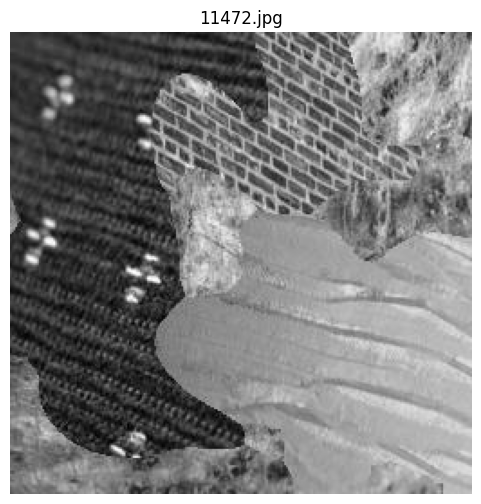

In [48]:
IMAGE_NAME = '11472.jpg'   # ← nom de l'image à tester

image = np.array(Image.open(os.path.join(IMAGE_DIR, IMAGE_NAME)).convert('RGB'))
h, w = image.shape[:2]
print(f'{IMAGE_NAME}  {w}×{h} px')
plt.figure(figsize=(7, 6))
plt.imshow(image); plt.title(IMAGE_NAME); plt.axis('off'); plt.show()

---
## Chargement d'une image zero-shot (sans ground truth)

Utilisez cette section pour tester **n'importe quelle image** :
- **Option A** : entrez un chemin absolu ou relatif au projet
- **Option B** : uploadez directement un fichier depuis votre PC

L'image chargée remplace `image` dans toutes les cellules suivantes.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

_zs_image = None


def _show_preview(img_array, label):
    with out_preview:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(img_array)
        h2, w2 = img_array.shape[:2]
        ax.set_title(f'{label}  —  {w2}×{h2} px', fontsize=10)
        ax.axis('off')
        plt.tight_layout()
        plt.show()


# Option A — chemin
path_input = widgets.Text(
    placeholder='/chemin/absolu/image.jpg  ou  relatif depuis le projet',
    description='Chemin :',
    layout=widgets.Layout(width='600px'),
    style={'description_width': '80px'}
)
btn_load_path = widgets.Button(
    description='📂 Charger depuis chemin',
    button_style='primary',
    layout=widgets.Layout(width='220px')
)

# Option B — upload
uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png,.bmp,.tiff,.tif,.webp',
    multiple=False,
    description='📤 Upload image',
    layout=widgets.Layout(width='200px')
)

# Bouton utiliser
btn_use = widgets.Button(
    description='✅ Utiliser cette image',
    button_style='success',
    layout=widgets.Layout(width='220px'),
    disabled=True
)
status_zs   = widgets.Label(value='Aucune image chargée.')
out_preview = widgets.Output()


def _on_load_path(_):
    global _zs_image
    p = Path(path_input.value.strip())
    if not p.is_absolute():
        p = ROOT / p
    if not p.exists():
        status_zs.value = f'❌ Fichier introuvable : {p}'
        btn_use.disabled = True
        return
    try:
        _zs_image = np.array(Image.open(p).convert('RGB'))
        status_zs.value = f'✓ Chargé : {p.name}'
        btn_use.disabled = False
        _show_preview(_zs_image, p.name)
    except Exception as e:
        status_zs.value = f'❌ Erreur : {e}'
        btn_use.disabled = True


def _on_upload(change):
    global _zs_image
    val = uploader.value
    if not val:
        return
    # ipywidgets >= 8 : val est un tuple de dicts avec clés name/content/...
    # ipywidgets <  8 : val est un dict  {filename: {name, content, ...}}
    if isinstance(val, (list, tuple)):
        entry = val[0]
        fname = entry['name']
        data  = entry['content']
    else:
        fname = list(val.keys())[0]
        data  = val[fname]['content']
    try:
        _zs_image = np.array(Image.open(io.BytesIO(bytes(data))).convert('RGB'))
        status_zs.value = f'✓ Uploadé : {fname}'
        btn_use.disabled = False
        _show_preview(_zs_image, fname)
    except Exception as e:
        status_zs.value = f'❌ Erreur : {e}'
        btn_use.disabled = True


def _on_use(_):
    global image, IMAGE_NAME, h, w, predictor
    if _zs_image is None:
        status_zs.value = "⚠ Chargez une image d'abord."
        return
    image      = _zs_image.copy()
    IMAGE_NAME = 'zero_shot'
    h, w       = image.shape[:2]
    predictor  = SAM2ImagePredictor(sam2_model)
    predictor.set_image(image)
    status_zs.value = f'✅ image active ({w}×{h} px) — exécutez les cellules suivantes.'
    btn_use.button_style = 'warning'
    btn_use.description  = '✅ Image active'


btn_load_path.on_click(_on_load_path)
uploader.observe(_on_upload, names='value')
btn_use.on_click(_on_use)

display(widgets.VBox([
    widgets.HTML('<b>Option A — chemin fichier</b>'),
    widgets.HBox([path_input, btn_load_path]),
    widgets.HTML('<b>Option B — upload depuis le PC</b>'),
    uploader,
    widgets.HTML('<hr>'),
    widgets.HBox([btn_use, status_zs]),
    out_preview,
]))

---
## Méthode 1 — Segmentation automatique

Génération...
7 masques


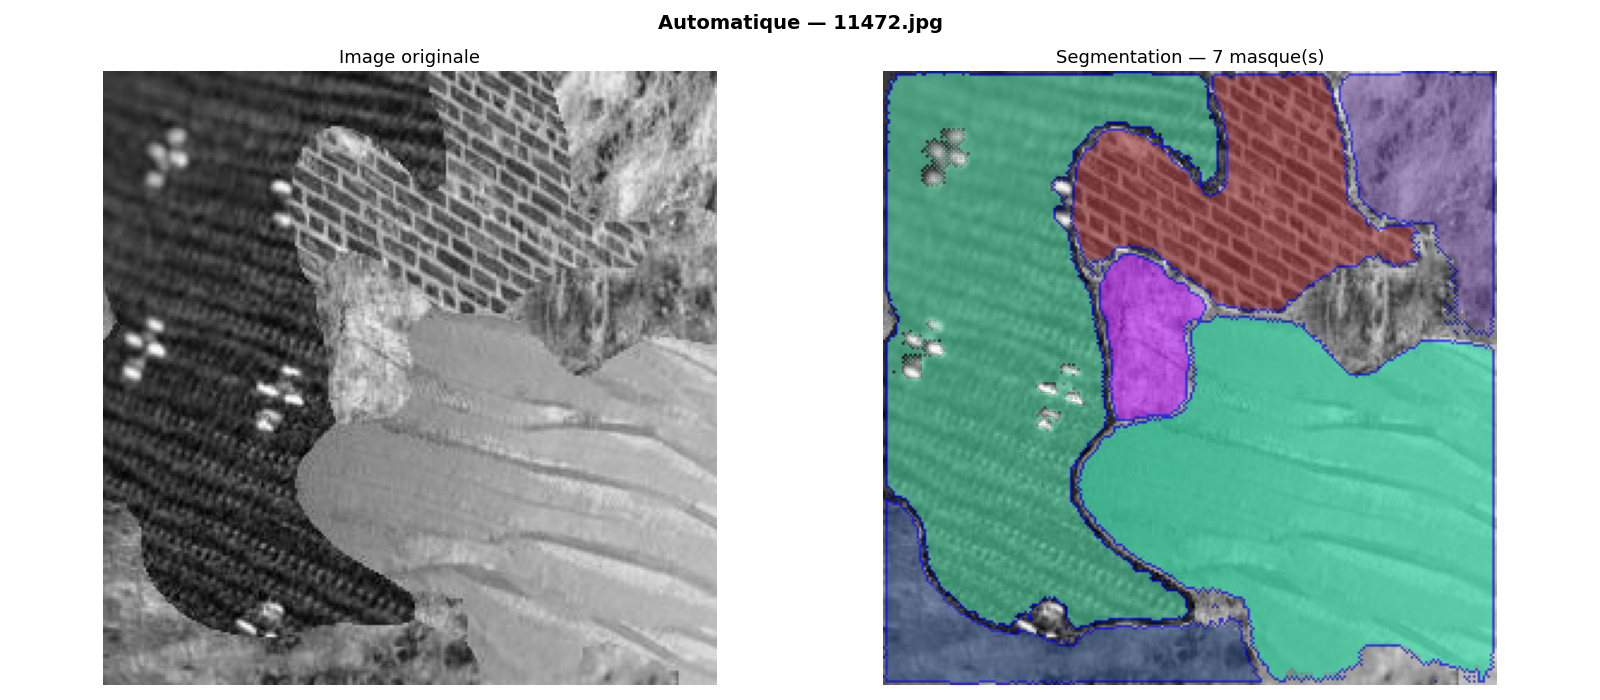

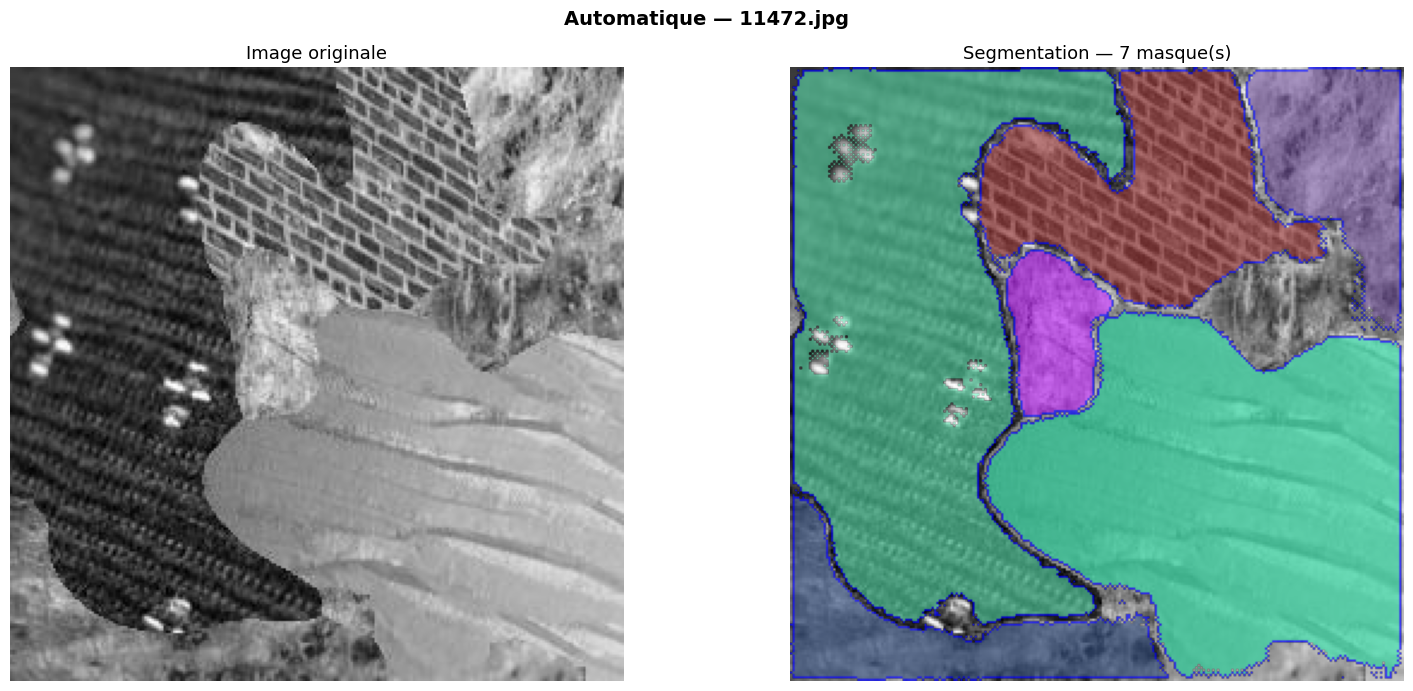

In [50]:
auto_gen = SAM2AutomaticMaskGenerator(
    model=sam2_model, points_per_side=64, pred_iou_thresh=0.8,
    stability_score_thresh=0.2, mask_threshold=0.0,
    min_mask_region_area=0, output_mode='binary_mask', multimask_output=False
)
print('Génération...')
auto_masks = auto_gen.generate(image)
print(f'{len(auto_masks)} masques')
show_masks(image, auto_masks, title=f'Automatique — {IMAGE_NAME}')

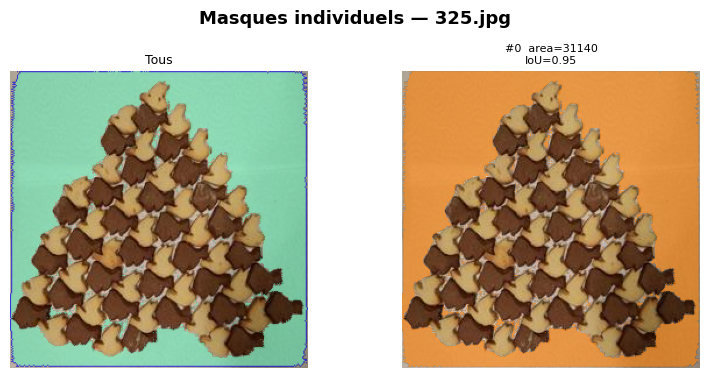

In [41]:
show_masks_grid(image, auto_masks, title=f'Masques individuels — {IMAGE_NAME}')

---
## Méthode 2 — Prompting par points (interactif)

**Clic gauche** → point d'inclusion (vert ★)  
**Clic droit** → point d'exclusion (rouge ✕)  
Bouton **Segmenter** → lance l'inférence  
Bouton **Reset** → efface tous les points

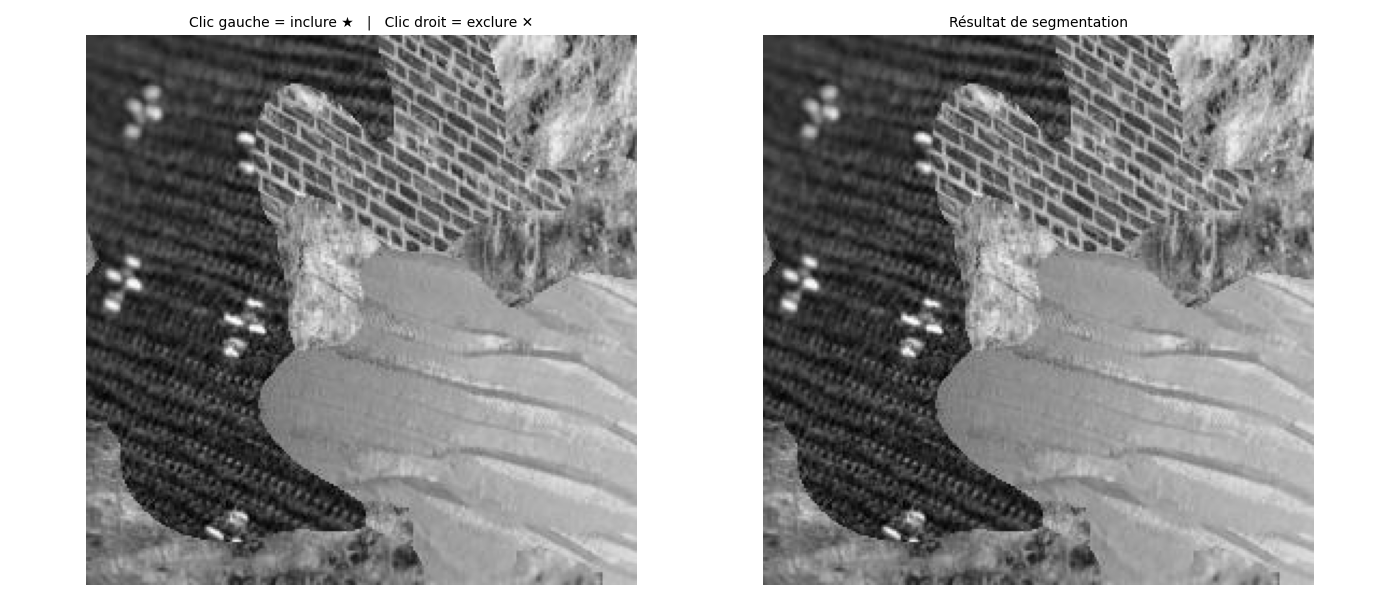

In [49]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display

# Préparer le predictor
predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(image)


class PointPromptUI:
    """Widget interactif : clic gauche = positif, clic droit = négatif."""

    def __init__(self, image, predictor):
        self.image = image
        self.predictor = predictor
        self.coords = []
        self.labels = []

        self.fig, self.axes = plt.subplots(1, 2, figsize=(14, 6))
        self.fig.canvas.header_visible = False

        self.axes[0].imshow(self.image)
        self.axes[0].set_title('Clic gauche = inclure ★   |   Clic droit = exclure ✕', fontsize=10)
        self.axes[0].axis('off')

        self.axes[1].imshow(self.image)
        self.axes[1].set_title('Résultat de segmentation', fontsize=10)
        self.axes[1].axis('off')

        self.fig.tight_layout()

        self.btn_seg   = widgets.Button(description='⚡ Segmenter',
                                        button_style='success', layout=widgets.Layout(width='160px'))
        self.btn_reset = widgets.Button(description='🗑 Reset',
                                        button_style='danger',  layout=widgets.Layout(width='120px'))
        self.btn_undo  = widgets.Button(description='↩ Annuler',
                                        button_style='warning', layout=widgets.Layout(width='120px'))
        self.status = widgets.Label(value="Cliquez sur l'image pour poser des points.")

        self.btn_seg.on_click(self._on_segment)
        self.btn_reset.on_click(self._on_reset)
        self.btn_undo.on_click(self._on_undo)

        self.fig.canvas.mpl_connect('button_press_event', self._on_click)

        toolbar = widgets.HBox([self.btn_seg, self.btn_undo, self.btn_reset, self.status])
        display(widgets.VBox([self.fig.canvas, toolbar]))

    def _on_click(self, event):
        if event.inaxes != self.axes[0]:
            return
        x, y = int(round(event.xdata)), int(round(event.ydata))
        label = 1 if event.button == 1 else 0
        self.coords.append([x, y])
        self.labels.append(label)
        self._redraw_points()
        kind = 'positif' if label == 1 else 'négatif'
        self.status.value = f"Point {kind} ajouté en ({x}, {y})  —  total: {len(self.coords)} pts"

    def _redraw_points(self):
        for artist in list(self.axes[0].lines):
            artist.remove()
        for (x, y), lbl in zip(self.coords, self.labels):
            self.axes[0].plot(x, y, '*' if lbl == 1 else 'x',
                              color='lime' if lbl == 1 else 'red',
                              markersize=14, markeredgewidth=2, zorder=5)
        self.fig.canvas.draw_idle()

    def _on_segment(self, _):
        if not self.coords:
            self.status.value = "⚠ Aucun point — cliquez d'abord sur l'image."
            return
        self.status.value = 'Segmentation en cours...'
        masks, scores, _ = self.predictor.predict(
            point_coords=np.array(self.coords),
            point_labels=np.array(self.labels),
            multimask_output=True
        )
        # predictor.predict retourne (N, H, W) en bool ou float32 selon la version
        masks_bool = [m.astype(bool) for m in masks]
        best = int(np.argmax(scores))
        self._draw_result(masks_bool, scores, best)
        self.status.value = (
            f'✓ {len(masks_bool)} masques  |  meilleur: #{best}  '
            f'IoU={scores[best]:.3f}  |  scores={scores.round(3).tolist()}'
        )

    def _draw_result(self, masks_bool, scores, best_idx):
        self.axes[1].cla()
        self.axes[1].imshow(self.image)
        colors = [[0.1, 0.6, 1.0], [0.9, 0.4, 0.1], [0.2, 0.85, 0.3]]

        # Autres masques en arrière-plan (transparence faible)
        for i, mask in enumerate(masks_bool):
            if i == best_idx:
                continue
            ov = np.zeros((*self.image.shape[:2], 4), np.float32)
            ov[mask] = colors[i % 3] + [0.20]
            self.axes[1].imshow(ov)

        # Meilleur masque en avant-plan
        ov_best = np.zeros((*self.image.shape[:2], 4), np.float32)
        ov_best[masks_bool[best_idx]] = colors[best_idx % 3] + [0.60]
        self.axes[1].imshow(ov_best)

        # Points
        for (x, y), lbl in zip(self.coords, self.labels):
            self.axes[1].plot(x, y, '*' if lbl == 1 else 'x',
                              color='lime' if lbl == 1 else 'red',
                              markersize=12, markeredgewidth=2, zorder=5)

        autres = [f'{s:.2f}' for j, s in enumerate(scores) if j != best_idx]
        self.axes[1].set_title(
            f'Masque #{best_idx} (meilleur)  IoU={scores[best_idx]:.3f}  |  autres: {autres}',
            fontsize=9)
        self.axes[1].axis('off')
        self.fig.canvas.draw_idle()

    def _on_reset(self, _):
        self.coords.clear()
        self.labels.clear()
        self._redraw_points()
        self.axes[1].cla()
        self.axes[1].imshow(self.image)
        self.axes[1].set_title('Résultat de segmentation', fontsize=10)
        self.axes[1].axis('off')
        self.fig.canvas.draw_idle()
        self.status.value = 'Points effacés.'

    def _on_undo(self, _):
        if self.coords:
            self.coords.pop()
            self.labels.pop()
            self._redraw_points()
            self.status.value = f'Dernier point supprimé  —  {len(self.coords)} pts restants'


ui = PointPromptUI(image, predictor)

---
## Méthode 3 — Prompting par boite englobante (Box)

In [ ]:
class BoxPromptUI:
    """Widget interactif : cliquer-glisser pour dessiner la boite englobante."""

    def __init__(self, image, predictor):
        self.image     = image
        self.predictor = predictor
        self.box       = None
        self._start    = None
        self._rect     = None

        self.fig, self.axes = plt.subplots(1, 2, figsize=(14, 6))
        self.fig.canvas.header_visible = False

        self.axes[0].imshow(self.image)
        self.axes[0].set_title('Cliquer-glisser pour définir la boite', fontsize=10)
        self.axes[0].axis('off')

        self.axes[1].imshow(self.image)
        self.axes[1].set_title('Résultat de segmentation', fontsize=10)
        self.axes[1].axis('off')

        self.fig.tight_layout()

        self.btn_seg   = widgets.Button(description='⚡ Segmenter',
                                        button_style='success',
                                        layout=widgets.Layout(width='160px'),
                                        disabled=True)
        self.btn_reset = widgets.Button(description='🗑 Reset',
                                        button_style='danger',
                                        layout=widgets.Layout(width='120px'))
        self.status = widgets.Label(value="Cliquez et glissez sur l'image pour dessiner la boite.")

        self.btn_seg.on_click(self._on_segment)
        self.btn_reset.on_click(self._on_reset)

        self.fig.canvas.mpl_connect('button_press_event',   self._on_press)
        self.fig.canvas.mpl_connect('motion_notify_event',  self._on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self._on_release)

        display(widgets.VBox([self.fig.canvas,
                               widgets.HBox([self.btn_seg, self.btn_reset, self.status])]))

    def _on_press(self, event):
        if event.inaxes != self.axes[0]:
            return
        self._start = (event.xdata, event.ydata)
        if self._rect:
            self._rect.remove()
            self._rect = None
        self.box = None
        self.btn_seg.disabled = True
        self.fig.canvas.draw_idle()

    def _on_motion(self, event):
        if self._start is None or event.inaxes != self.axes[0]:
            return
        x0, y0 = self._start
        x1, y1 = event.xdata, event.ydata
        if self._rect:
            self._rect.remove()
        self._rect = patches.Rectangle(
            (min(x0, x1), min(y0, y1)), abs(x1 - x0), abs(y1 - y0),
            linewidth=2, edgecolor='lime', facecolor='lime', alpha=0.15, linestyle='--'
        )
        self.axes[0].add_patch(self._rect)
        self.fig.canvas.draw_idle()

    def _on_release(self, event):
        if self._start is None:
            return
        if event.inaxes != self.axes[0]:
            self._start = None
            return
        x0, y0 = self._start
        x1, y1 = event.xdata, event.ydata
        self._start = None
        if abs(x1 - x0) < 5 or abs(y1 - y0) < 5:
            self.status.value = '⚠ Boite trop petite — recommencez.'
            return
        self.box = np.array([min(x0,x1), min(y0,y1), max(x0,x1), max(y0,y1)], dtype=int)
        if self._rect:
            self._rect.remove()
        self._rect = patches.Rectangle(
            (self.box[0], self.box[1]), self.box[2]-self.box[0], self.box[3]-self.box[1],
            linewidth=2.5, edgecolor='lime', facecolor='none'
        )
        self.axes[0].add_patch(self._rect)
        self.fig.canvas.draw_idle()
        self.btn_seg.disabled = False
        self.status.value = (f'Boite : [{self.box[0]}, {self.box[1]}, '
                             f'{self.box[2]}, {self.box[3]}]  — cliquez Segmenter')

    def _on_segment(self, _):
        if self.box is None:
            return
        self.status.value = 'Segmentation en cours...'
        masks, scores, _ = self.predictor.predict(
            point_coords=None, point_labels=None,
            box=self.box.astype(float), multimask_output=False
        )
        mask = masks[0].astype(bool)
        ov = np.zeros((*self.image.shape[:2], 4), np.float32)
        ov[mask] = [0.9, 0.3, 0.1, 0.55]
        self.axes[1].cla()
        self.axes[1].imshow(self.image)
        self.axes[1].imshow(ov)
        self.axes[1].add_patch(patches.Rectangle(
            (self.box[0], self.box[1]), self.box[2]-self.box[0], self.box[3]-self.box[1],
            linewidth=2.5, edgecolor='lime', facecolor='none'
        ))
        self.axes[1].set_title(f'Masque  IoU={scores[0]:.3f}', fontsize=11)
        self.axes[1].axis('off')
        self.fig.canvas.draw_idle()
        self.status.value = f'✓ Segmenté  IoU={scores[0]:.3f}'

    def _on_reset(self, _):
        if self._rect:
            self._rect.remove()
            self._rect = None
        self.box    = None
        self._start = None
        self.axes[0].cla()
        self.axes[0].imshow(self.image)
        self.axes[0].set_title('Cliquer-glisser pour définir la boite', fontsize=10)
        self.axes[0].axis('off')
        self.axes[1].cla()
        self.axes[1].imshow(self.image)
        self.axes[1].set_title('Résultat de segmentation', fontsize=10)
        self.axes[1].axis('off')
        self.fig.canvas.draw_idle()
        self.btn_seg.disabled = True
        self.status.value = "Boite effacée — recommencez."


box_ui = BoxPromptUI(image, predictor)

---
## Méthode 4 — Combinaison Box + Points

In [ ]:
class BoxPointPromptUI:
    """Widget interactif : cliquer-glisser = boite, puis clic G/D = points d'inclusion/exclusion."""

    def __init__(self, image, predictor):
        self.image     = image
        self.predictor = predictor
        self.box       = None
        self._start    = None
        self._rect     = None
        self.coords    = []
        self.labels    = []
        self._mode     = 'box'   # 'box' → 'points' après la boite

        self.fig, self.axes = plt.subplots(1, 2, figsize=(14, 6))
        self.fig.canvas.header_visible = False

        self.axes[0].imshow(self.image)
        self.axes[0].set_title('Étape 1 — Cliquer-glisser pour définir la boite', fontsize=10)
        self.axes[0].axis('off')

        self.axes[1].imshow(self.image)
        self.axes[1].set_title('Résultat de segmentation', fontsize=10)
        self.axes[1].axis('off')

        self.fig.tight_layout()

        self.btn_seg   = widgets.Button(description='⚡ Segmenter',
                                        button_style='success',
                                        layout=widgets.Layout(width='160px'),
                                        disabled=True)
        self.btn_undo  = widgets.Button(description='↩ Annuler pt',
                                        button_style='warning',
                                        layout=widgets.Layout(width='130px'))
        self.btn_reset = widgets.Button(description='🗑 Reset',
                                        button_style='danger',
                                        layout=widgets.Layout(width='120px'))
        self.status = widgets.Label(value="Étape 1 : dessinez la boite (cliquer-glisser).")

        self.btn_seg.on_click(self._on_segment)
        self.btn_undo.on_click(self._on_undo)
        self.btn_reset.on_click(self._on_reset)

        self.fig.canvas.mpl_connect('button_press_event',   self._on_press)
        self.fig.canvas.mpl_connect('motion_notify_event',  self._on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self._on_release)

        display(widgets.VBox([
            self.fig.canvas,
            widgets.HBox([self.btn_seg, self.btn_undo, self.btn_reset, self.status])
        ]))

    def _on_press(self, event):
        if event.inaxes != self.axes[0]:
            return
        if self._mode == 'box':
            self._start = (event.xdata, event.ydata)
            if self._rect:
                self._rect.remove()
                self._rect = None
            self.fig.canvas.draw_idle()
        else:
            x, y  = int(round(event.xdata)), int(round(event.ydata))
            label = 1 if event.button == 1 else 0
            self.coords.append([x, y])
            self.labels.append(label)
            self._redraw_left()
            kind = 'positif ★' if label == 1 else 'négatif ✕'
            self.status.value = (f'Point {kind} ({x},{y}) — '
                                 f'{len(self.coords)} pt(s)  |  cliquez Segmenter')

    def _on_motion(self, event):
        if self._mode != 'box' or self._start is None or event.inaxes != self.axes[0]:
            return
        x0, y0 = self._start
        x1, y1 = event.xdata, event.ydata
        if self._rect:
            self._rect.remove()
        self._rect = patches.Rectangle(
            (min(x0,x1), min(y0,y1)), abs(x1-x0), abs(y1-y0),
            linewidth=2, edgecolor='yellow', facecolor='yellow', alpha=0.15, linestyle='--'
        )
        self.axes[0].add_patch(self._rect)
        self.fig.canvas.draw_idle()

    def _on_release(self, event):
        if self._mode != 'box' or self._start is None:
            return
        if event.inaxes != self.axes[0]:
            self._start = None
            return
        x0, y0 = self._start
        x1, y1 = event.xdata, event.ydata
        self._start = None
        if abs(x1-x0) < 5 or abs(y1-y0) < 5:
            self.status.value = '⚠ Boite trop petite — recommencez.'
            return
        self.box = np.array([min(x0,x1), min(y0,y1), max(x0,x1), max(y0,y1)], dtype=int)
        if self._rect:
            self._rect.remove()
        self._rect = patches.Rectangle(
            (self.box[0], self.box[1]), self.box[2]-self.box[0], self.box[3]-self.box[1],
            linewidth=2.5, edgecolor='yellow', facecolor='none'
        )
        self.axes[0].add_patch(self._rect)
        self.fig.canvas.draw_idle()
        self._mode = 'points'
        self.btn_seg.disabled = False
        self.status.value = ('Boite définie ✓  —  Étape 2 : ajoutez des points '
                             '(clic gauche=inclure, clic droit=exclure) puis Segmenter.')

    def _redraw_left(self):
        self.axes[0].cla()
        self.axes[0].imshow(self.image)
        if self.box is not None:
            self.axes[0].add_patch(patches.Rectangle(
                (self.box[0], self.box[1]), self.box[2]-self.box[0], self.box[3]-self.box[1],
                linewidth=2.5, edgecolor='yellow', facecolor='none'
            ))
        for (x, y), lbl in zip(self.coords, self.labels):
            self.axes[0].plot(x, y, '*' if lbl == 1 else 'x',
                              color='lime' if lbl == 1 else 'red',
                              markersize=14, markeredgewidth=2, zorder=5)
        n = len(self.coords)
        title = ('Étape 1 — Cliquer-glisser pour définir la boite'
                 if self._mode == 'box'
                 else f'Boite + {n} point(s)  (clic G=inclure  clic D=exclure)')
        self.axes[0].set_title(title, fontsize=9)
        self.axes[0].axis('off')
        self.fig.canvas.draw_idle()

    def _on_segment(self, _):
        if self.box is None:
            return
        self.status.value = 'Segmentation en cours...'
        kw = dict(box=self.box.astype(float), multimask_output=False)
        if self.coords:
            kw['point_coords'] = np.array(self.coords)
            kw['point_labels'] = np.array(self.labels)
        masks, scores, _ = self.predictor.predict(**kw)
        mask = masks[0].astype(bool)
        ov = np.zeros((*self.image.shape[:2], 4), np.float32)
        ov[mask] = [0.2, 0.8, 0.2, 0.55]
        self.axes[1].cla()
        self.axes[1].imshow(self.image)
        self.axes[1].imshow(ov)
        self.axes[1].add_patch(patches.Rectangle(
            (self.box[0], self.box[1]), self.box[2]-self.box[0], self.box[3]-self.box[1],
            linewidth=2.5, edgecolor='yellow', facecolor='none'
        ))
        for (x, y), lbl in zip(self.coords, self.labels):
            self.axes[1].plot(x, y, '*' if lbl == 1 else 'x',
                              color='lime' if lbl == 1 else 'red',
                              markersize=12, markeredgewidth=2, zorder=5)
        self.axes[1].set_title(
            f'Box + {len(self.coords)} pt(s)  IoU={scores[0]:.3f}', fontsize=11)
        self.axes[1].axis('off')
        self.fig.canvas.draw_idle()
        self.status.value = f'✓ Segmenté  IoU={scores[0]:.3f}'

    def _on_undo(self, _):
        if self.coords:
            self.coords.pop()
            self.labels.pop()
            self._redraw_left()
            self.status.value = f'Dernier point supprimé — {len(self.coords)} pt(s) restants'

    def _on_reset(self, _):
        self.box    = None
        self._start = None
        self._rect  = None
        self.coords.clear()
        self.labels.clear()
        self._mode = 'box'
        self.btn_seg.disabled = True
        self.axes[0].cla()
        self.axes[0].imshow(self.image)
        self.axes[0].set_title('Étape 1 — Cliquer-glisser pour définir la boite', fontsize=10)
        self.axes[0].axis('off')
        self.axes[1].cla()
        self.axes[1].imshow(self.image)
        self.axes[1].set_title('Résultat de segmentation', fontsize=10)
        self.axes[1].axis('off')
        self.fig.canvas.draw_idle()
        self.status.value = 'Réinitialisé — dessinez une nouvelle boite.'


box_pt_ui = BoxPointPromptUI(image, predictor)

---
## Comparaison des 3 checkpoints

In [ ]:
CHECKPOINTS = {
    'SAM-2.1 original':  'checkpoints/sam2.1_hiera_small',
    'TextureSAM η≤0.3':  'checkpoints/sam2.1_hiera_small_0.3',
    'TextureSAM η≤1':    'checkpoints/sam2.1_hiera_small_1.pt',
}
GEN_PARAMS = dict(
    points_per_side=64, pred_iou_thresh=0.8, stability_score_thresh=0.2,
    mask_threshold=0.0, min_mask_region_area=0, output_mode='binary_mask', multimask_output=False
)

all_results = {}
for name, ckpt in CHECKPOINTS.items():
    print(f'Chargement {name}...')
    m = load_model(ckpt)
    g = SAM2AutomaticMaskGenerator(model=m, **GEN_PARAMS)
    masks = g.generate(image)
    all_results[name] = masks
    print(f'  → {len(masks)} masques')
print('Terminé.')

In [ ]:
n = len(all_results)
fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 6))
axes[0].imshow(image); axes[0].set_title('Original', fontsize=11); axes[0].axis('off')
for i, (name, masks) in enumerate(all_results.items()):
    axes[i+1].imshow(image); axes[i+1].imshow(build_overlay(image, masks))
    axes[i+1].set_title(f'{name}\n{len(masks)} masques', fontsize=10); axes[i+1].axis('off')
plt.suptitle(f'Comparaison checkpoints — {IMAGE_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Sauvegarder les résultats

In [ ]:
%matplotlib inline

OUTPUT_DIR = ROOT / 'outputs' / 'test_prompting'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
stem = Path(IMAGE_NAME).stem

fig = show_masks(image, auto_masks, title=f'Automatique — {IMAGE_NAME}')
fig.savefig(OUTPUT_DIR / f'{stem}_auto.png', dpi=120, bbox_inches='tight')

masks_dir = OUTPUT_DIR / f'{stem}_masks'
masks_dir.mkdir(exist_ok=True)
for i, m in enumerate(auto_masks):
    Image.fromarray((m['segmentation'].astype(np.uint8)) * 255).save(
        masks_dir / f'mask_{i}_{stem}.png')

print(f'Sauvegardé dans {OUTPUT_DIR}/')
print(f'{len(auto_masks)} masques dans {masks_dir}/')